In [1]:
import google.auth
credentials, PROJECT_ID= google.auth.default()
print(credentials)
print(PROJECT_ID)

anbc-hcb-dev


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_embeddings` 
"""
kmdo = client.query(sql).to_dataframe() 
kmdo.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,0.012551,-0.801091,-0.954232,-0.063742,0.068830,0.531503,-0.963184,-0.451365,0.230133,-0.452478,...,-0.183085,0.654447,-0.796245,-0.673659,1.095727,-0.173602,0.100395,-0.669587,-0.231344,351475974
1,0.170071,-0.152534,-0.589442,-0.049022,-0.436744,0.596911,-0.733354,-0.172703,0.612856,-0.332520,...,0.052351,0.333924,-0.566642,-0.899665,0.744085,-0.148200,-0.075404,-0.541967,-0.541533,281773290
2,0.529800,-0.016500,-1.087361,0.462913,-0.123339,0.351587,-0.985915,-0.403847,0.127912,-0.939542,...,-0.000381,0.377394,-0.703374,-1.373493,0.723459,0.919604,-0.570315,-1.276104,-0.253252,351726462
3,-0.774433,-0.523120,-0.687653,0.164111,-0.741208,0.610536,-0.756409,-0.429213,0.682624,-0.452592,...,0.312815,0.121807,-0.307922,-0.502669,1.373911,0.394225,0.257746,-0.734794,-0.300540,480508345
4,-0.286435,-0.241780,-0.907755,0.512192,-0.535176,0.722167,-1.417763,-1.352646,0.461377,-0.286820,...,0.251769,0.310729,-0.260849,-0.463852,0.448644,0.381718,-0.295716,-0.344881,-0.233660,460864660


In [4]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_member` 
"""
mem = client.query(sql).to_dataframe() 
mem.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group
0,480549669,48,VA,2023-06-01,DD,ABD
1,480259079,48,VA,2023-06-01,DD,ABD
2,480252173,48,VA,2023-06-01,DD,ABD
3,480269246,48,VA,2023-06-01,DD,ABD
4,480243870,48,VA,2023-06-01,DD,ABD


In [5]:
print(mem['coa_population_group'].value_counts())

TANF/CHIP    1566888
Expansion     731116
ABD           158875
BH            118451
LTSS           81785
Dual Elig      77420
Other          67490
Dual Int       46358
Name: coa_population_group, dtype: int64


In [6]:
mem = mem.rename(columns={"asdb_member_key": "individual_id"})

In [7]:
kmdo_mem = mem.merge(kmdo, on='individual_id', how='left')
kmdo_mem = kmdo_mem.assign(embed_type = 'komodo_integrated')
kmdo_mem.fillna(value = 0, inplace = True)

In [8]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcomes_revised` 
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.head()

,asdb_member_key,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,351656309,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
1,331200138,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
2,281682248,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
3,590027491,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
4,480450216,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0


In [9]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_mem.merge(outcomes, on='individual_id', how='left')

In [10]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_tenure` 
"""
tenure = client.query(sql).to_dataframe() 
tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
0,480266556,48,VA,2023-06-01,DD,ABD,13
1,480155331,48,VA,2023-06-01,DD,ABD,13
2,480325456,48,VA,2023-06-01,DD,ABD,13
3,480559161,48,VA,2023-06-01,DD,ABD,13
4,480241619,48,VA,2023-06-01,DD,ABD,13


In [11]:
tenure = tenure.rename(columns={"asdb_member_key": "individual_id"})
tenure = tenure.set_index('individual_id')

In [12]:
pd.crosstab(tenure['tenure'], tenure['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [13]:
kmdo_outcome = kmdo_outcome.merge(tenure, on='individual_id', how='left')

In [14]:
kmdo_outcome.columns

Index(['individual_id', 'asdb_plan_key_x', 'asdb_plan_nm_x', 'asdb_elig_dt_x',
       'coa_population_category_x', 'coa_population_group_x', 'emb0', 'emb1',
       'emb2', 'emb3',
       ...
       'ed_flag', 'sum_avoidable', 'sum_unnecessary', 'sum_preventable',
       'asdb_plan_key_y', 'asdb_plan_nm_y', 'asdb_elig_dt_y',
       'coa_population_category_y', 'coa_population_group_y', 'tenure'],
      dtype='object', length=281)

In [15]:
#kmdo_outcome.fillna(value = 0, inplace = True)
kmdo_outcome.head()

,individual_id,asdb_plan_key_x,asdb_plan_nm_x,asdb_elig_dt_x,coa_population_category_x,coa_population_group_x,emb0,emb1,emb2,emb3,...,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable,asdb_plan_key_y,asdb_plan_nm_y,asdb_elig_dt_y,coa_population_category_y,coa_population_group_y,tenure
0,480549669,48,VA,2023-06-01,DD,ABD,-0.261453,-0.281986,-0.370268,-0.481285,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
1,480259079,48,VA,2023-06-01,DD,ABD,-0.774998,-1.062835,-0.523414,-0.001344,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
2,480252173,48,VA,2023-06-01,DD,ABD,-1.132274,-0.851320,-0.759962,0.452026,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
3,480269246,48,VA,2023-06-01,DD,ABD,-0.241650,-0.451317,-0.809169,-0.276600,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13
4,480243870,48,VA,2023-06-01,DD,ABD,-0.176572,-0.401363,-0.134512,-0.528827,...,0,0,0,0,48,VA,2023-06-01,DD,ABD,13


In [16]:
print(kmdo_outcome['acute_ip_flag'].value_counts())

0    2802354
1      46029
Name: acute_ip_flag, dtype: Int64


In [17]:
kmdo_outcome = kmdo_outcome.set_index('individual_id')

In [18]:
#split dataset in features and target variable
X = kmdo_outcome.iloc[:, 5:261] # Features
y = kmdo_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
individual_id,,,,,,,,,,,,,,,,,,,,,
480549669,-0.261453,-0.281986,-0.370268,-0.481285,-0.172689,0.386090,-0.262375,-0.080802,0.273391,-0.436318,...,-0.051042,0.535433,-0.351474,-0.182122,-1.017723,1.213209,-0.259637,0.902767,-0.314621,-0.624035
480259079,-0.774998,-1.062835,-0.523414,-0.001344,-0.487451,1.051111,-0.348348,-0.618865,1.063814,-0.632719,...,0.293257,0.389004,-0.216932,-0.666167,-1.000277,1.268754,0.333476,0.728531,-0.566598,-0.319060
480252173,-1.132274,-0.851320,-0.759962,0.452026,-0.467887,0.398539,-0.558074,-0.697433,0.724436,-1.041982,...,0.886506,0.395972,-0.179766,-1.042719,-0.908483,0.826495,0.265484,0.363924,-0.409165,-0.206639
480269246,-0.241650,-0.451317,-0.809169,-0.276600,-0.467808,0.190261,-0.293865,0.094386,0.173321,-0.363021,...,0.242904,0.217992,0.059000,-0.134249,-0.641268,1.048481,-0.244051,0.072409,-0.681704,-0.300918
480243870,-0.176572,-0.401363,-0.134512,-0.528827,0.066894,0.459076,-0.342017,-0.124068,0.023495,-0.194669,...,-0.171732,-0.088275,-0.044713,-0.352701,-0.385827,1.115213,-0.371026,0.774977,-0.205365,-0.604021


In [19]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [20]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [21]:
y_pred = logreg.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(712096, 1)

In [22]:
threshold = 0.3

y_predict_prob =logreg.predict_proba(X_test)[:, 1]
y_predict_lab = ((logreg.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,698803,1662
1,10626,1005


In [23]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[698803,   1662],
       [ 10626,   1005]])

Text(0.5, 427.9555555555555, 'Predicted label')

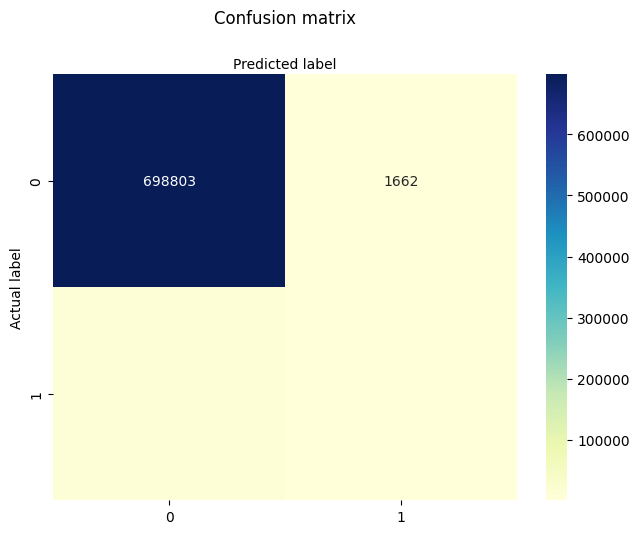

In [24]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [25]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      1.00      0.99    700465
     with IP       0.38      0.09      0.14     11631

    accuracy                           0.98    712096
   macro avg       0.68      0.54      0.57    712096
weighted avg       0.98      0.98      0.98    712096



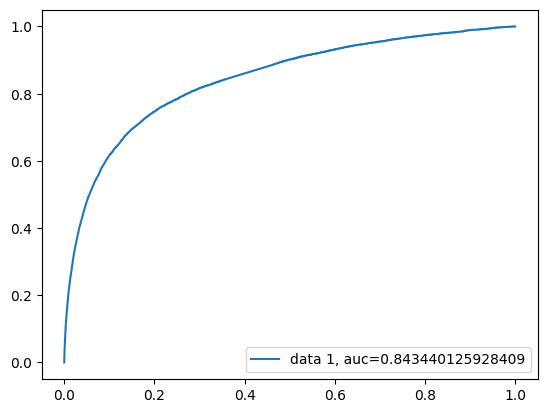

In [26]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

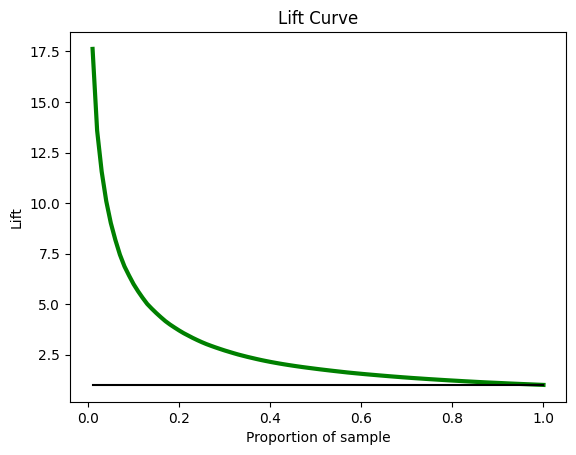

In [27]:
# Function that plots a Lift Curve using the real label values of a dataset and the probability predictions of a Machine Learning Algorithm/model
# @Params:
# y_val: real labels of the data
# y_pred: probability predictions for such data
# step: how big we want the steps in the percentiles to be

# imports
import numpy as np
import pandas as pd

def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_proba, step=0.01)

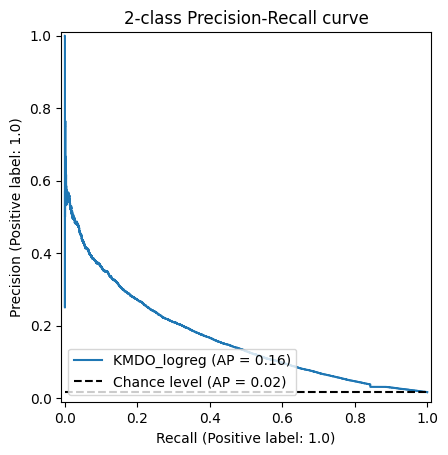

In [28]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    logreg, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [29]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [30]:
lift_chart(X_test, y_test, logreg)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.671091,0.197379,2050,7121,1.000006,17.625312,17.625312,1.000006,17.625213
1,0.197376,0.131057,1110,7121,1.000006,9.543461,27.168773,2.000011,13.58431
2,0.131056,0.098799,872,7121,1.000006,7.497206,34.665979,3.000017,11.555261
3,0.098797,0.078903,665,7121,1.000006,5.717479,40.383458,4.000022,10.095808
4,0.078902,0.065342,546,7121,1.000006,4.694351,45.077809,5.000028,9.015511
...,...,...,...,...,...,...,...,...,...
95,0.001462,0.001380,18,7121,1.000006,0.154759,99.647494,95.999978,1.037995
96,0.001380,0.001292,15,7121,1.000006,0.128966,99.776459,96.999983,1.028623
97,0.001292,0.001187,8,7121,1.000006,0.068782,99.845241,97.999989,1.018829
98,0.001187,0.001050,10,7121,1.000006,0.085977,99.931218,98.999994,1.009406


In [31]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [32]:
df_out = pd.merge(y_pred, tenure, how = 'left',left_index = True, right_index = True)

In [33]:
df_out.shape
df_out.head()

,acute_ip_flag,y_predict_prob,y_predict_class,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,,,,
480582906,0,0.003578,0,48,VA,2023-06-01,TANF,TANF/CHIP,12
540067120,0,0.012255,0,54,CA,2023-06-01,TANF,TANF/CHIP,13
590224138,0,0.007209,0,59,KS,2023-06-01,TANF,TANF/CHIP,2
480327569,0,0.212117,0,48,VA,2023-06-01,Expansion,Expansion,13
72191412,0,0.019761,0,7,MCP,2023-06-01,TANF,TANF/CHIP,13


In [35]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df    

In [36]:
lift_chart(df_out[df_out['tenure'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.561388,0.015980,326,4662,10.000215,41.006289,41.006289,10.000215,4.100541
1,0.015980,0.008356,79,4662,10.000215,9.937107,50.943396,20.000429,2.547115
2,0.008356,0.007209,54,4662,10.000215,6.792453,57.735849,30.000644,1.924487
3,0.007209,0.007209,73,4662,10.000215,9.18239,66.918239,40.000858,1.67292
4,0.007209,0.007209,69,4662,10.000215,8.679245,75.597484,50.001073,1.511917
5,0.007209,0.007209,46,4661,9.998069,5.786164,81.383648,59.999142,1.356414
6,0.007209,0.007209,44,4662,10.000215,5.534591,86.918239,69.999356,1.241701
7,0.007209,0.004873,54,4662,10.000215,6.792453,93.710692,79.999571,1.17139
8,0.004873,0.002945,31,4662,10.000215,3.899371,97.610063,89.999785,1.084559
9,0.002945,0.000551,19,4662,10.000215,2.389937,100.0,100.000000,1.0


In [37]:
lift_chart(df_out[df_out['tenure'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.558408,0.020868,597,7296,10.001234,54.027149,54.027149,10.001234,5.402048
1,0.020867,0.010706,130,7295,9.999863,11.764706,65.791855,20.001097,3.289412
2,0.010705,0.007308,96,7295,9.999863,8.687783,74.479638,30.000960,2.482575
3,0.007307,0.007209,43,7295,9.999863,3.891403,78.371041,40.000822,1.959236
4,0.007209,0.006628,62,7295,9.999863,5.61086,83.9819,50.000685,1.679615
5,0.006628,0.004987,43,7295,9.999863,3.891403,87.873303,60.000548,1.464542
6,0.004987,0.003742,38,7295,9.999863,3.438914,91.312217,70.000411,1.304453
7,0.003742,0.002786,42,7295,9.999863,3.800905,95.113122,80.000274,1.18891
8,0.002785,0.001982,36,7295,9.999863,3.257919,98.371041,90.000137,1.09301
9,0.001981,0.000509,18,7295,9.999863,1.628959,100.0,100.000000,1.0


In [38]:
lift_chart(df_out[df_out['tenure'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.671091,0.036538,6037,59253,10.000068,62.038845,62.038845,10.000068,6.203843
1,0.036537,0.016643,1420,59253,10.000068,14.592539,76.631384,20.000135,3.831543
2,0.016643,0.009964,732,59252,9.999899,7.522351,84.153735,30.000034,2.805121
3,0.009964,0.007209,402,59253,10.000068,4.131127,88.284863,40.000101,2.207116
4,0.007209,0.006035,278,59252,9.999899,2.856849,91.141712,50.000000,1.822834
5,0.006035,0.004401,275,59253,10.000068,2.82602,93.967732,60.000068,1.566127
6,0.004401,0.003253,189,59252,9.999899,1.942246,95.909978,69.999966,1.370143
7,0.003253,0.002429,160,59253,10.000068,1.64423,97.554208,80.000034,1.219427
8,0.002429,0.001765,138,59252,9.999899,1.418148,98.972356,89.999932,1.099694
9,0.001765,0.000351,100,59253,10.000068,1.027644,100.0,100.000000,1.0


In [39]:
m0_3 = df_out.loc[df_out['tenure'].isin([0,1,2,3,])]
m4_8 = df_out.loc[df_out['tenure'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[df_out['tenure'].isin([9,10,11,12,13,])]

In [44]:
print("% admitted post 6 months 0-3m cohort: ", m0_3['acute_ip_flag'].mean()*100)
print("% admitted post 6 months 4-8m cohort: ", m4_8['acute_ip_flag'].mean()*100)
print("% admitted post 6 months established cohort: ", m_9_13['acute_ip_flag'].mean()*100)

% admitted post 6 months 0-3m cohort:  1.705313284283232
% admitted post 6 months 4-8m cohort:  1.5147153568833873
% admitted post 6 months established cohort:  1.6422908024289231


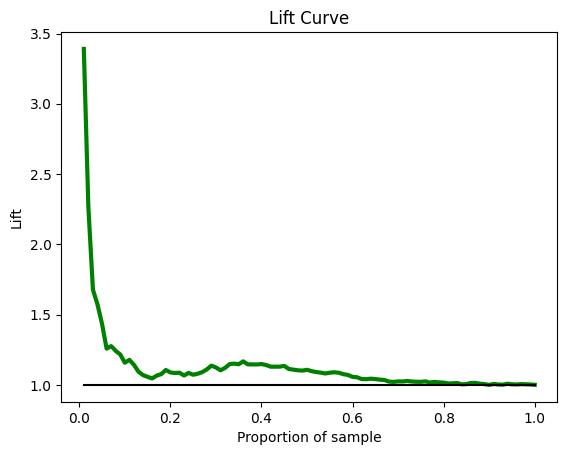

In [40]:
plot_lift_curve(m0_3['acute_ip_flag'], m0_3['y_predict_class'], step=0.01)

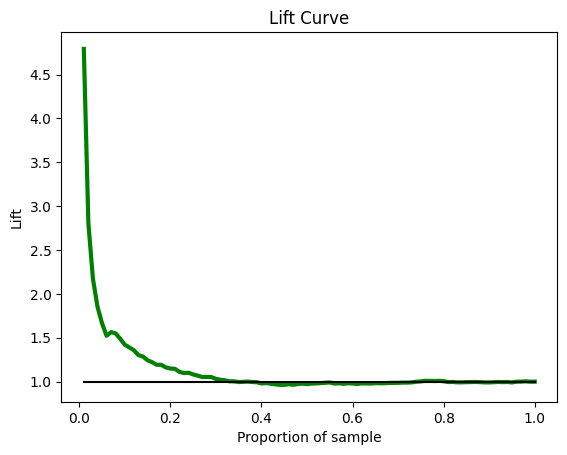

In [41]:
plot_lift_curve(m4_8['acute_ip_flag'], m4_8['y_predict_class'], step=0.01)

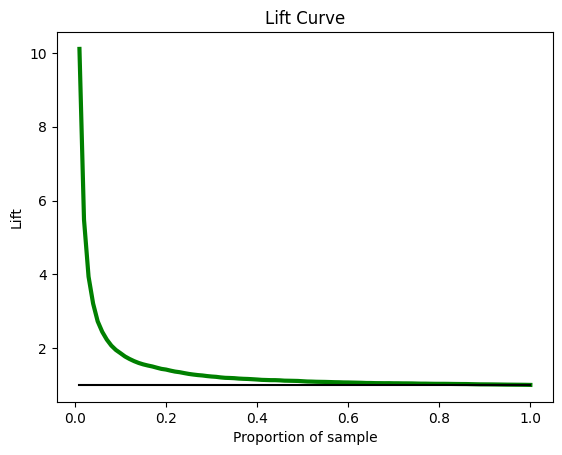

In [42]:
plot_lift_curve(m_9_13['acute_ip_flag'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
from joblib import dump, load
dump(logreg, 'Medicaid_IP_embeddings_only_logreg.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

In [ ]:
# create the data, or the data that is to be estimated
data = data.drop('TOTAL_DAYS_TO_COMPLETE', axis=1)

# Remove the order number since we don't need it
order_numbers = data['ORDER_NUMBER']
data = data.drop('ORDER_NUMBER', axis=1)

# # split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size = 0.2)

rf = RandomForestRegressor(
    bootstrap = True,
    max_depth = None,
    max_features = 'sqrt',
    min_samples_leaf = 1,
    min_samples_split = 2,
    n_estimators  = 5000
)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_differences = compare_values(y_test, rf_predictions)
rf_Avg = np.average(rf_differences)
print("#################################################")
print("DATA FOR RANDOM FORESTS")
print(rf_Avg)
importances = get_feature_importances(X_test.columns, rf.feature_importances_)
print()
print(importances)

res = y_test.to_frame('Actual Value')
res.insert(0, 'Predicted Value', rf_predictions)
res = order_numbers.to_frame().join(res, how='inner')
print(res)